# Time evolution of t-J model

In [20]:
%load_ext autoreload
%autoreload 2

import numpy as np

from ncon import ncon

from scipy.sparse import csc_array, kron
import scipy.sparse as sp
from scipy.linalg import svd, norm

from qs_mps.sparse_hamiltonians_and_operators import diagonalization, U_evolution_sparse
from qs_mps.mps_class import MPS
from qs_mps.utils import tensor_shapes, mps_to_vector, logarithm_base_d, mpo_to_matrix

import matplotlib.pyplot as plt

# default parameters of the plot layout
plt.rcParams["text.usetex"] = True  # use latex
plt.rcParams["font.size"] = 13
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.constrained_layout.use"] = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Exact

In [21]:
# Single-site identity
Id = sp.identity(3, format="csr").toarray()
O = csc_array((3, 3), dtype=complex).toarray()

# Spin operators
Sz = (1/2) * sp.diags([1, 0, -1], 0, format="csr")

S_plus  = sp.csr_matrix([[0, 0, 1],
                         [0, 0, 0],
                         [0, 0, 0]])

S_minus = sp.csr_matrix([[0, 0, 0],
                         [0, 0, 0],
                         [1, 0, 0]])

# Hole hopping operators

# hole goes into a spin up state
T_up_h   = sp.csr_matrix([[0, 1, 0],
                          [0, 0, 0],
                          [0, 0, 0]])

# hole goes into a spin down state
T_down_h = sp.csr_matrix([[0, 0, 0],
                          [0, 0, 0],
                          [0, 1, 0]])

# spin up goes into a hole state
T_h_up   = sp.csr_matrix([[0, 0, 0],
                          [1, 0, 0],
                          [0, 0, 0]])

# spin down goes into a hole state
T_h_down = sp.csr_matrix([[0, 0, 0],
                          [0, 0, 1],
                          [0, 0, 0]])

# Hole number operator
n_h = sp.csr_matrix([[0, 0, 0],
                     [0, 1, 0],
                     [0, 0, 0]])

In [22]:
def kron_sparse_op(Op, i, n):
    if (i > 1) and (i < n):
        left = Id
        right = Id
        for k in range(1,i-1):
            left = kron(left, Id)
        for k in range(i+1,n):
            right = kron(Id, right)
        return kron(kron(left, Op),right)
    elif i == 1:
        right = Id
        for k in range(i+1,n):
            right = kron(Id, right)
        return kron(Op,right)
    elif i == n:
        left = Id
        for k in range(1,i-1):
            left = kron(left, Id)        
        return kron(left, Op)

# Heisenberg ham
def heis_ham(n, Jz, J_perp, eps):
    # zz-int
    H_zz = sp.csr_matrix((3**n,3**n))
    if Jz != 0:
        for i in range(1,n):
            H_zz += kron_sparse_op(Sz,i,n) @ kron_sparse_op(Sz,i+1,n)
    
    # pm-int
    H_pm = sp.csr_matrix((3**n,3**n))
    if J_perp != 0:
        for i in range(1,n):
            H_pm += kron_sparse_op(S_plus,i,n) @ kron_sparse_op(S_minus,i+1,n)
    
    # pm-int
    H_mp = sp.csr_matrix((3**n,3**n))
    if J_perp != 0:
        for i in range(1,n):
            H_mp += kron_sparse_op(S_minus,i,n) @ kron_sparse_op(S_plus,i+1,n)
    
    # breaking degeneracy (if eps<0 -> up, if eps>0 -> down)
    H_z = sp.csr_matrix((3**n,3**n))
    if eps != 0:
        for i in range(1,n+1):
            H_z += kron_sparse_op(Sz,i,n)

    return Jz * H_zz + (J_perp / 2) * (H_pm + H_mp) + eps * H_z

# hopping ham
def hop_ham(n, t_up, t_down):
    # up-hole
    H_uh = sp.csr_matrix((3**n,3**n))
    if t_up != 0:
        for i in range(1,n):
            H_uh += kron_sparse_op(T_up_h,i,n) @ kron_sparse_op(T_h_up,i+1,n)

    # hole-up
    H_hu = sp.csr_matrix((3**n,3**n))
    if t_up != 0:
        for i in range(1,n):
            H_hu += kron_sparse_op(T_h_up,i,n) @ kron_sparse_op(T_up_h,i+1,n)
    
    # down-hole
    H_dh = sp.csr_matrix((3**n,3**n))
    if t_down != 0:
        for i in range(1,n):
            H_dh += kron_sparse_op(T_down_h,i,n) @ kron_sparse_op(T_h_down,i+1,n)

    # hole-down
    H_hd = sp.csr_matrix((3**n,3**n))
    if t_down != 0:
        for i in range(1,n):
            H_hd += kron_sparse_op(T_h_down,i,n) @ kron_sparse_op(T_down_h,i+1,n)
    

    return - t_up * (H_uh + H_hu) - t_down * (H_dh + H_hd)

# holes ham
def hol_ham(n, V):
    # zz-int
    H_hh = sp.csr_matrix((3**n,3**n))
    if V != 0:
        for i in range(1,n):
            H_hh += kron_sparse_op(n_h,i,n) @ kron_sparse_op(n_h,i+1,n)
    
    return V * H_hh

def tJV_ham(n, t_up, t_down, Jz, J_perp, eps, V):
    H_t = hop_ham(n=n, t_up=t_up, t_down=t_down)
    H_J = heis_ham(n=n, Jz=Jz, J_perp=J_perp, eps=eps)
    H_V = hol_ham(n=n, V=V)

    return H_t + H_J + H_V

In [23]:
def hole_occupation(n):
    nh = sp.csr_matrix((3**n, 3**n))
    for i in range(1, n+1):
        nh += kron_sparse_op(n_h, i, n)
    return nh/n

def local_hole_occupation(n):
    return [kron_sparse_op(n_h, i, n) for i in range(1, n+1)]

def local_mag_occupation(n):
    return [kron_sparse_op(2*Sz, i, n) for i in range(1, n+1)]

def total_magnetization(n):
    M = sp.csr_matrix((3**n, 3**n))
    for i in range(1, n+1):
        M += kron_sparse_op(2*Sz, i, n)
    return M/n

def staggered_total_magnetization(n):
    M = sp.csr_matrix((3**n, 3**n))
    for i in range(1, n+1):
        if (i % 2) == 0:
            M -= kron_sparse_op(2*Sz, i, n)
        elif (i % 2) == 1:
            M += kron_sparse_op(2*Sz, i, n)
    return M

In [ ]:
def half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, n_holes=1):
    H_tJ_0 = tJV_ham(n=half_chain_length, t_up=t_up, t_down=t_down, Jz=Jz, J_perp=J_perp, eps=eps, V=V)
    e, v = diagonalization(H_tJ_0, sparse=False)
    psi_init_side = v[:,0]

    # mps_ancilla_side = MPS(half_chain_length, 3, "tj", chi=100)
    # # mps_ancilla_side.vector_to_mps(psi_init_side, trunc_chi=False, trunc_tol=True)
    # # mps_ancilla_side.vector_to_mps(psi_init_side, trunc_chi=False, trunc_tol=True, ancilla=True)
    # mps_ancilla_side.vector_to_mps(psi_init_side, trunc_chi=True, trunc_tol=False, ancilla=True)
    # mps_ancilla_side.vector_to_mps(psi_init_side, trunc_chi=True, trunc_tol=False)
    # mps_ancilla_side.flipping_all_tj(ancilla=True)
    # # mps_ancilla_side.canonical_form(ancilla=True)
    # tensor_shapes(mps_ancilla_side.sites)
    # print("-----------")
    # tensor_shapes(mps_ancilla_side.ancilla_sites)
    # hole_state = np.array([[0,1,0]]).reshape((1,3,1))
    # mps_init = mps_ancilla_side.sites + [hole_state]*n_holes + mps_ancilla_side.ancilla_sites
    # mps = MPS(2*half_chain_length+n_holes, 3, "tj", chi=100)
    # mps.sites = mps_init
    # mps.canonical_form()
    # psi_init = mps_to_vector(mps.sites)
    # # psi_init = mps_to_vector(mps_init)

    psi_init_left = psi_init_side.copy()
    # psi_init_right = psi_init_side.copy()

    psi_init_right = psi_init_side.copy()
    # psi_init_right[3::4] = psi_init_right[1::4]
    # psi_init_right[1::4] = psi_init_side[3::4].copy()
    # psi_init_right[2::4] = psi_init_right[2::4][::-1]

    psi_hole = np.array([0,1,0])
    psi_init = kron(kron(psi_init_left, psi_hole), psi_init_right).T.toarray()
    # psi_init = kron(kron(psi_init_left, psi_hole), psi_init_left).T.toarray()
    psi_init = psi_init.reshape(3**(2*half_chain_length+n_holes))

    # print(psi_init.shape)

    H_tJ_ev = tJV_ham(n=2*half_chain_length+n_holes, t_up=t_up, t_down=t_down, Jz=Jz, J_perp=J_perp, eps=eps, V=V)

    return H_tJ_ev, psi_init

def half_hole_quench_evolution(half_chain_length, H_tJ_ev, psi_init, trotter_steps, final_time, obs=[], n_holes=1, save=False):
    psi_ev = psi_init.copy()

    exp_vals = []
    psi_save = []

    if len(obs) == 0:
        obs = ['h_loc']
    
    if 'h_loc' in obs:
        ops_h = local_hole_occupation(2*half_chain_length + n_holes)

    if 'm_loc' in obs:
        ops_m = local_mag_occupation(2*half_chain_length + n_holes)

    occup_tot_h = []
    occup_tot_m = []

    for trott in range(trotter_steps):
        print(f"Trotter step: {trott}")
        psi_ev = U_evolution_sparse(psi_init=psi_ev, H_ev=H_tJ_ev, trotter=trotter_steps, time=final_time)
        if save:
            psi_save.append(psi_ev.copy())
        
        if 'h_loc' in obs:
            occup = []
            for op in ops_h:
                occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
                # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
            occup_tot_h.append(occup)
    
        if 'm_loc' in obs:
            occup = []
            for op in ops_m:
                occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
                # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
            occup_tot_m.append(occup)
    
    exp_vals.append(occup_tot_h)
    exp_vals.append(occup_tot_m)
    return exp_vals, psi_save

In [212]:
half_chain_length = 2
t_up = 2
t_down = 2
Jz = 10
J_perp = 0
eps = 0
V = 0
trotter_steps = 100
final_time = 2

In [213]:
spin_up = np.array([1,0,0])
hole = np.array([0,1,0])
spin_down = np.array([0,0,1])

H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, n_holes=1)

# psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_down, kron(spin_up, spin_down))))))).T.toarray()
# psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_down, kron(spin_up, spin_down))))))).T.toarray()
# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(hole, kron(spin_up, kron(spin_up, kron(hole, kron(hole, hole))))))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(spin_up, kron(hole, hole)))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(spin_up, kron(spin_up, kron(hole, hole))))).T.toarray()
# psi_init = psi_init.reshape((3**6))
# psi_init = psi_init.reshape((3**8))

# H_ev = tJV_ham(n=2*half_chain_length+2, t_up=t_up, t_down=t_down, Jz=Jz, J_perp=J_perp, eps=eps, V=V)
exp_vals, psi_save = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time, obs=['h_loc', 'm_loc'], n_holes=1, save=True)

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

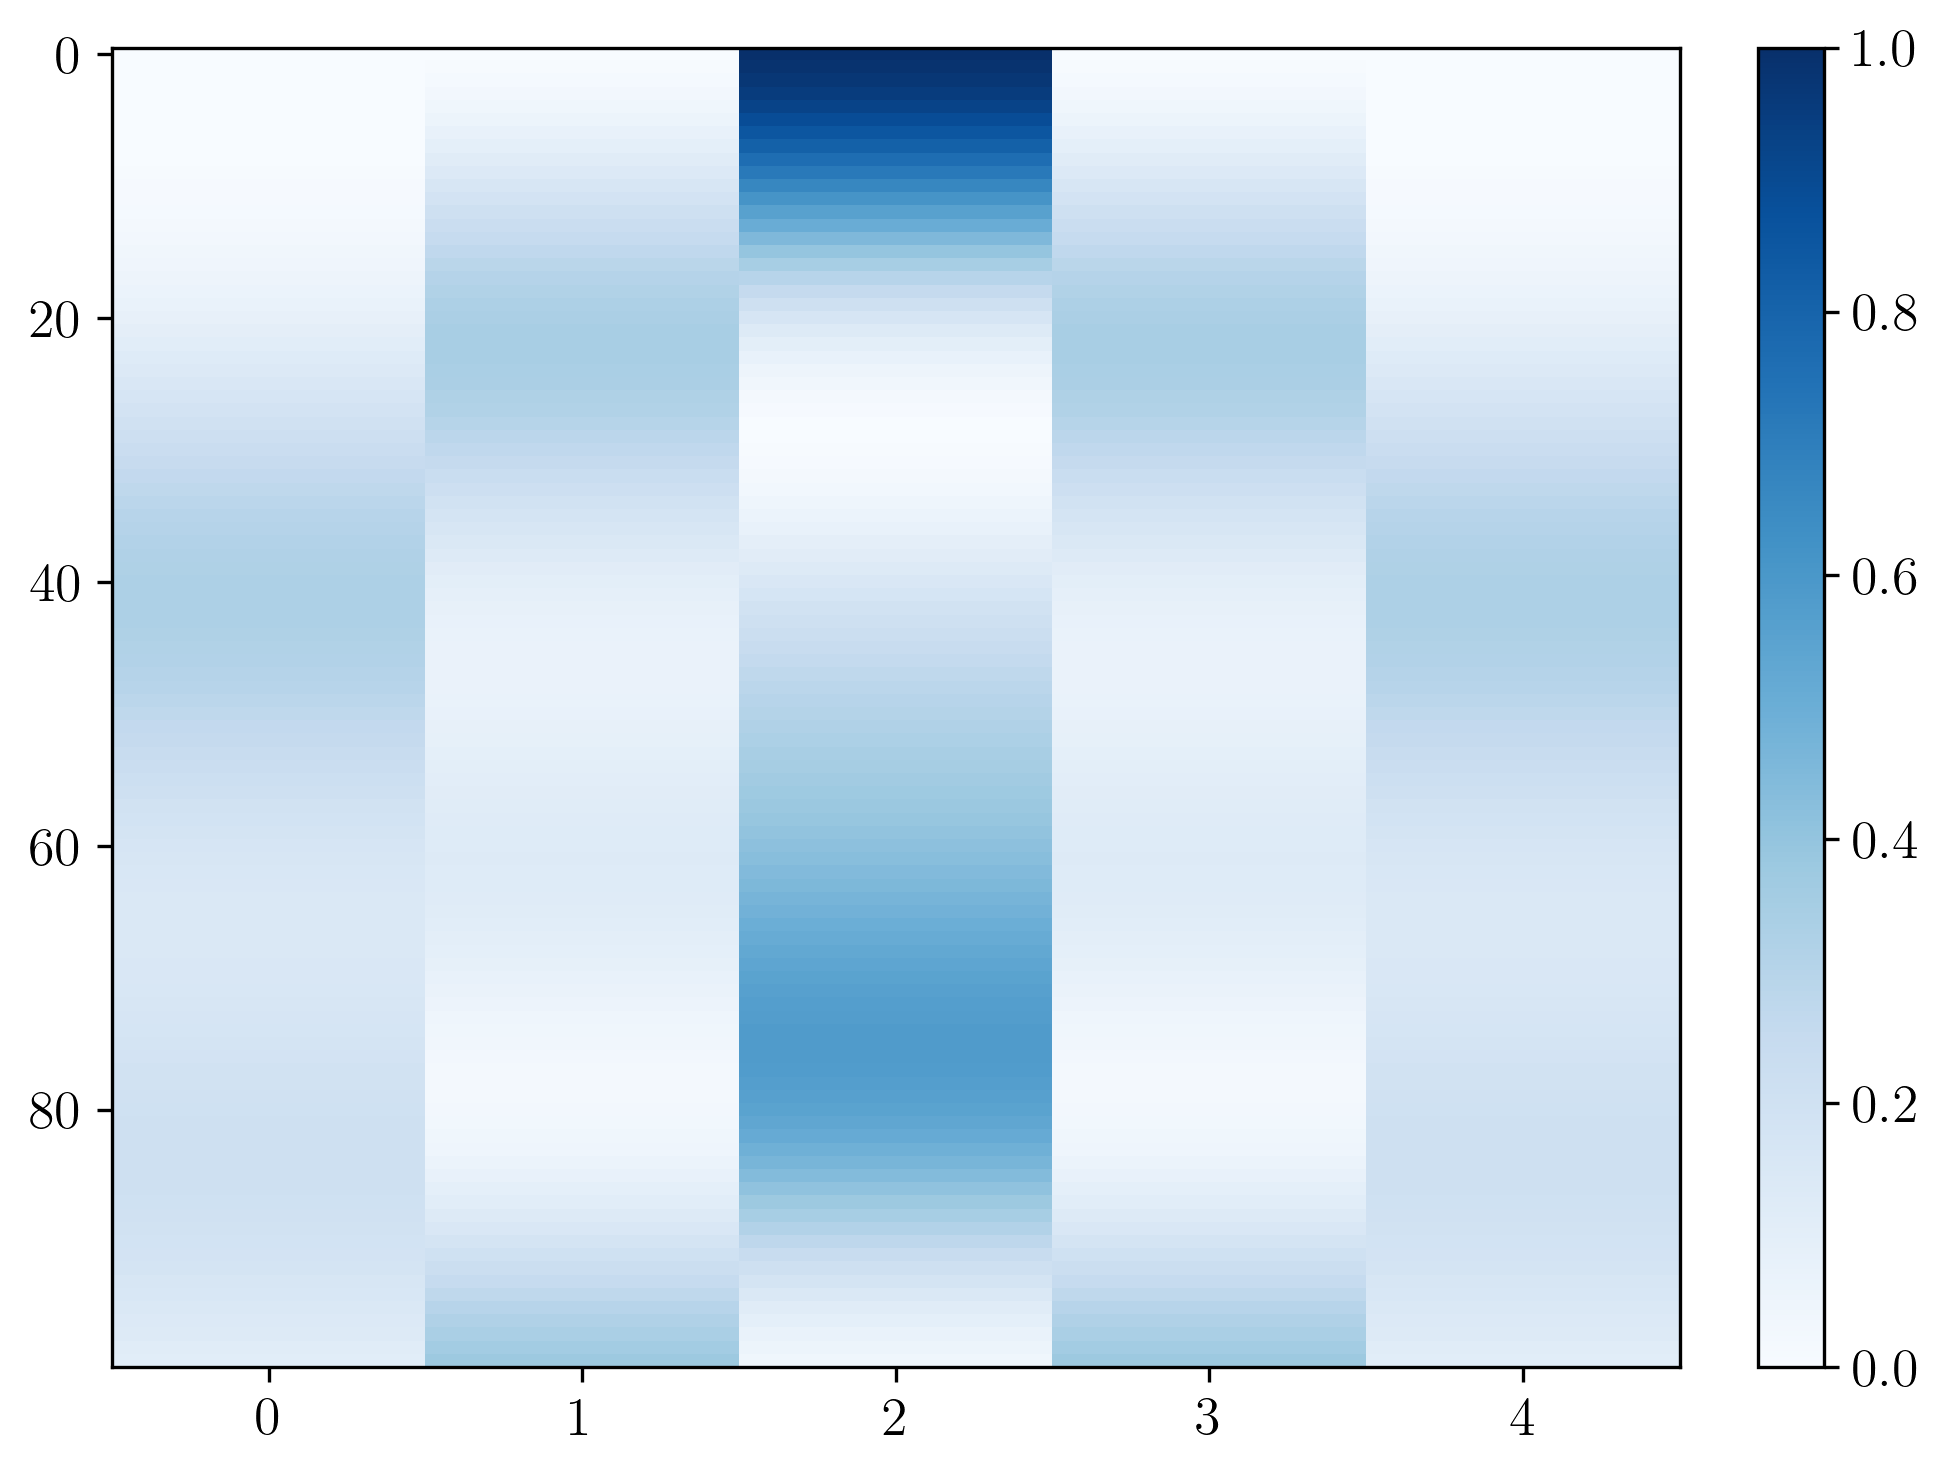

In [214]:
# plt.imshow(np.asarray(exp_vals[1]), vmin=-1, vmax=1, aspect='auto', cmap='seismic')
plt.imshow(np.asarray(exp_vals[0]), vmin=0, vmax=1, aspect='auto', cmap='Blues')
plt.colorbar()

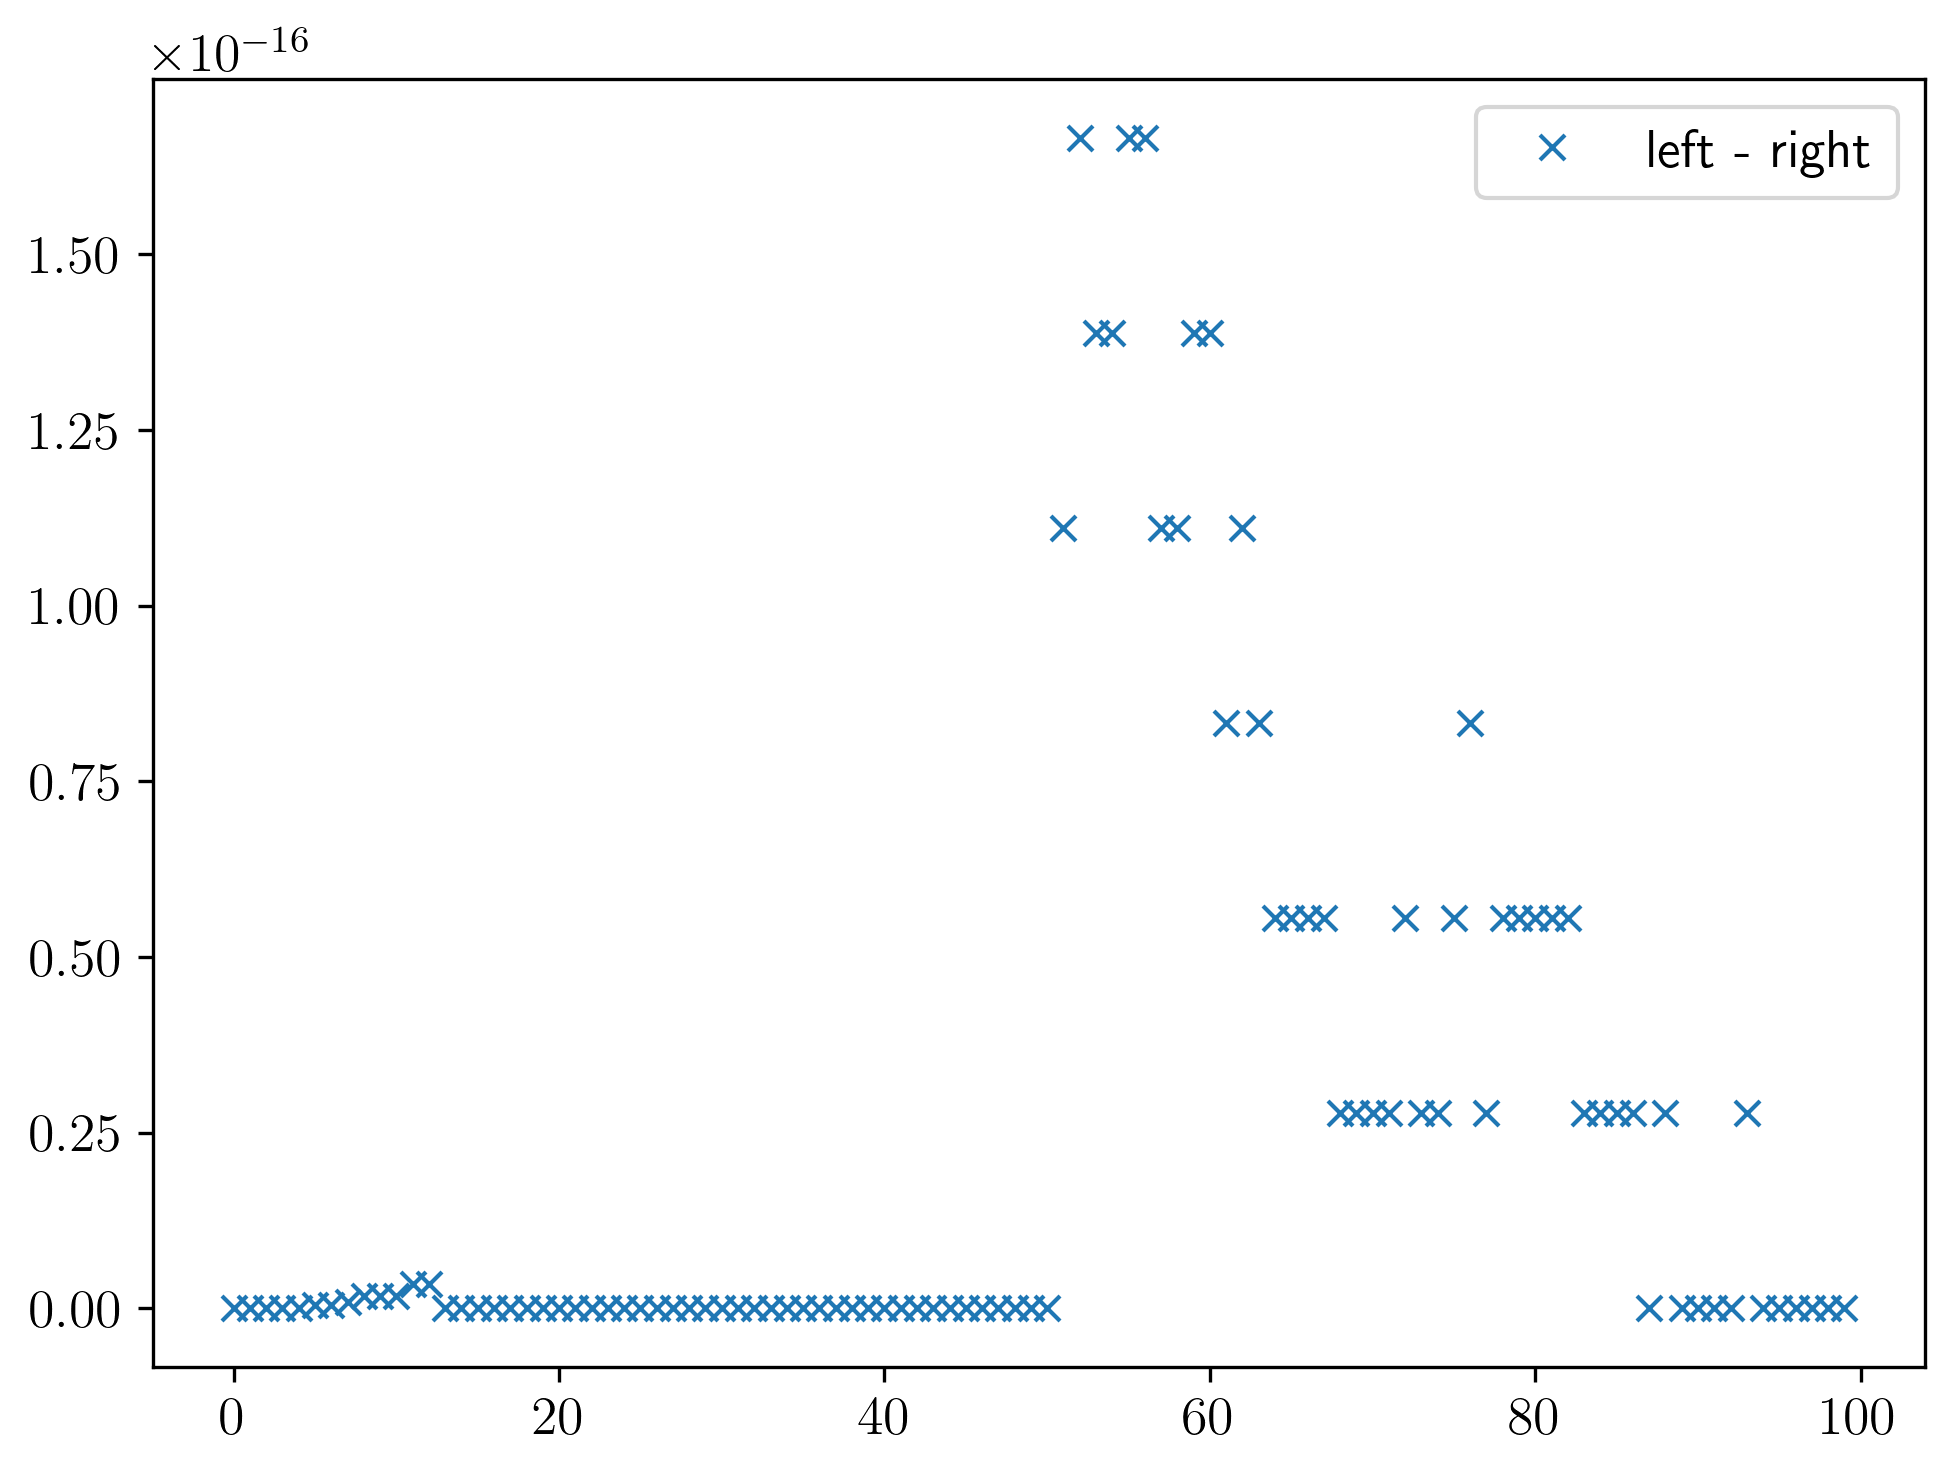

In [126]:
# plt.plot(np.asarray(exp_vals[0])[:,2],'+', label='left')
# plt.plot(np.asarray(exp_vals[0])[:,5],'x', label='right')
plt.plot(np.abs(np.asarray(exp_vals[0])[:,0] - np.asarray(exp_vals[0])[:,4]),'x', label='left - right')
plt.legend()

In [128]:
half_chain_length = 2
t_up = 0.1
t_down = 0.1
Jz = 10
J_perp = 1
eps = 0
V = 0
trotter_steps = 100
final_time = 2

In [ ]:
H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V)
occup_tot, _ = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time)

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

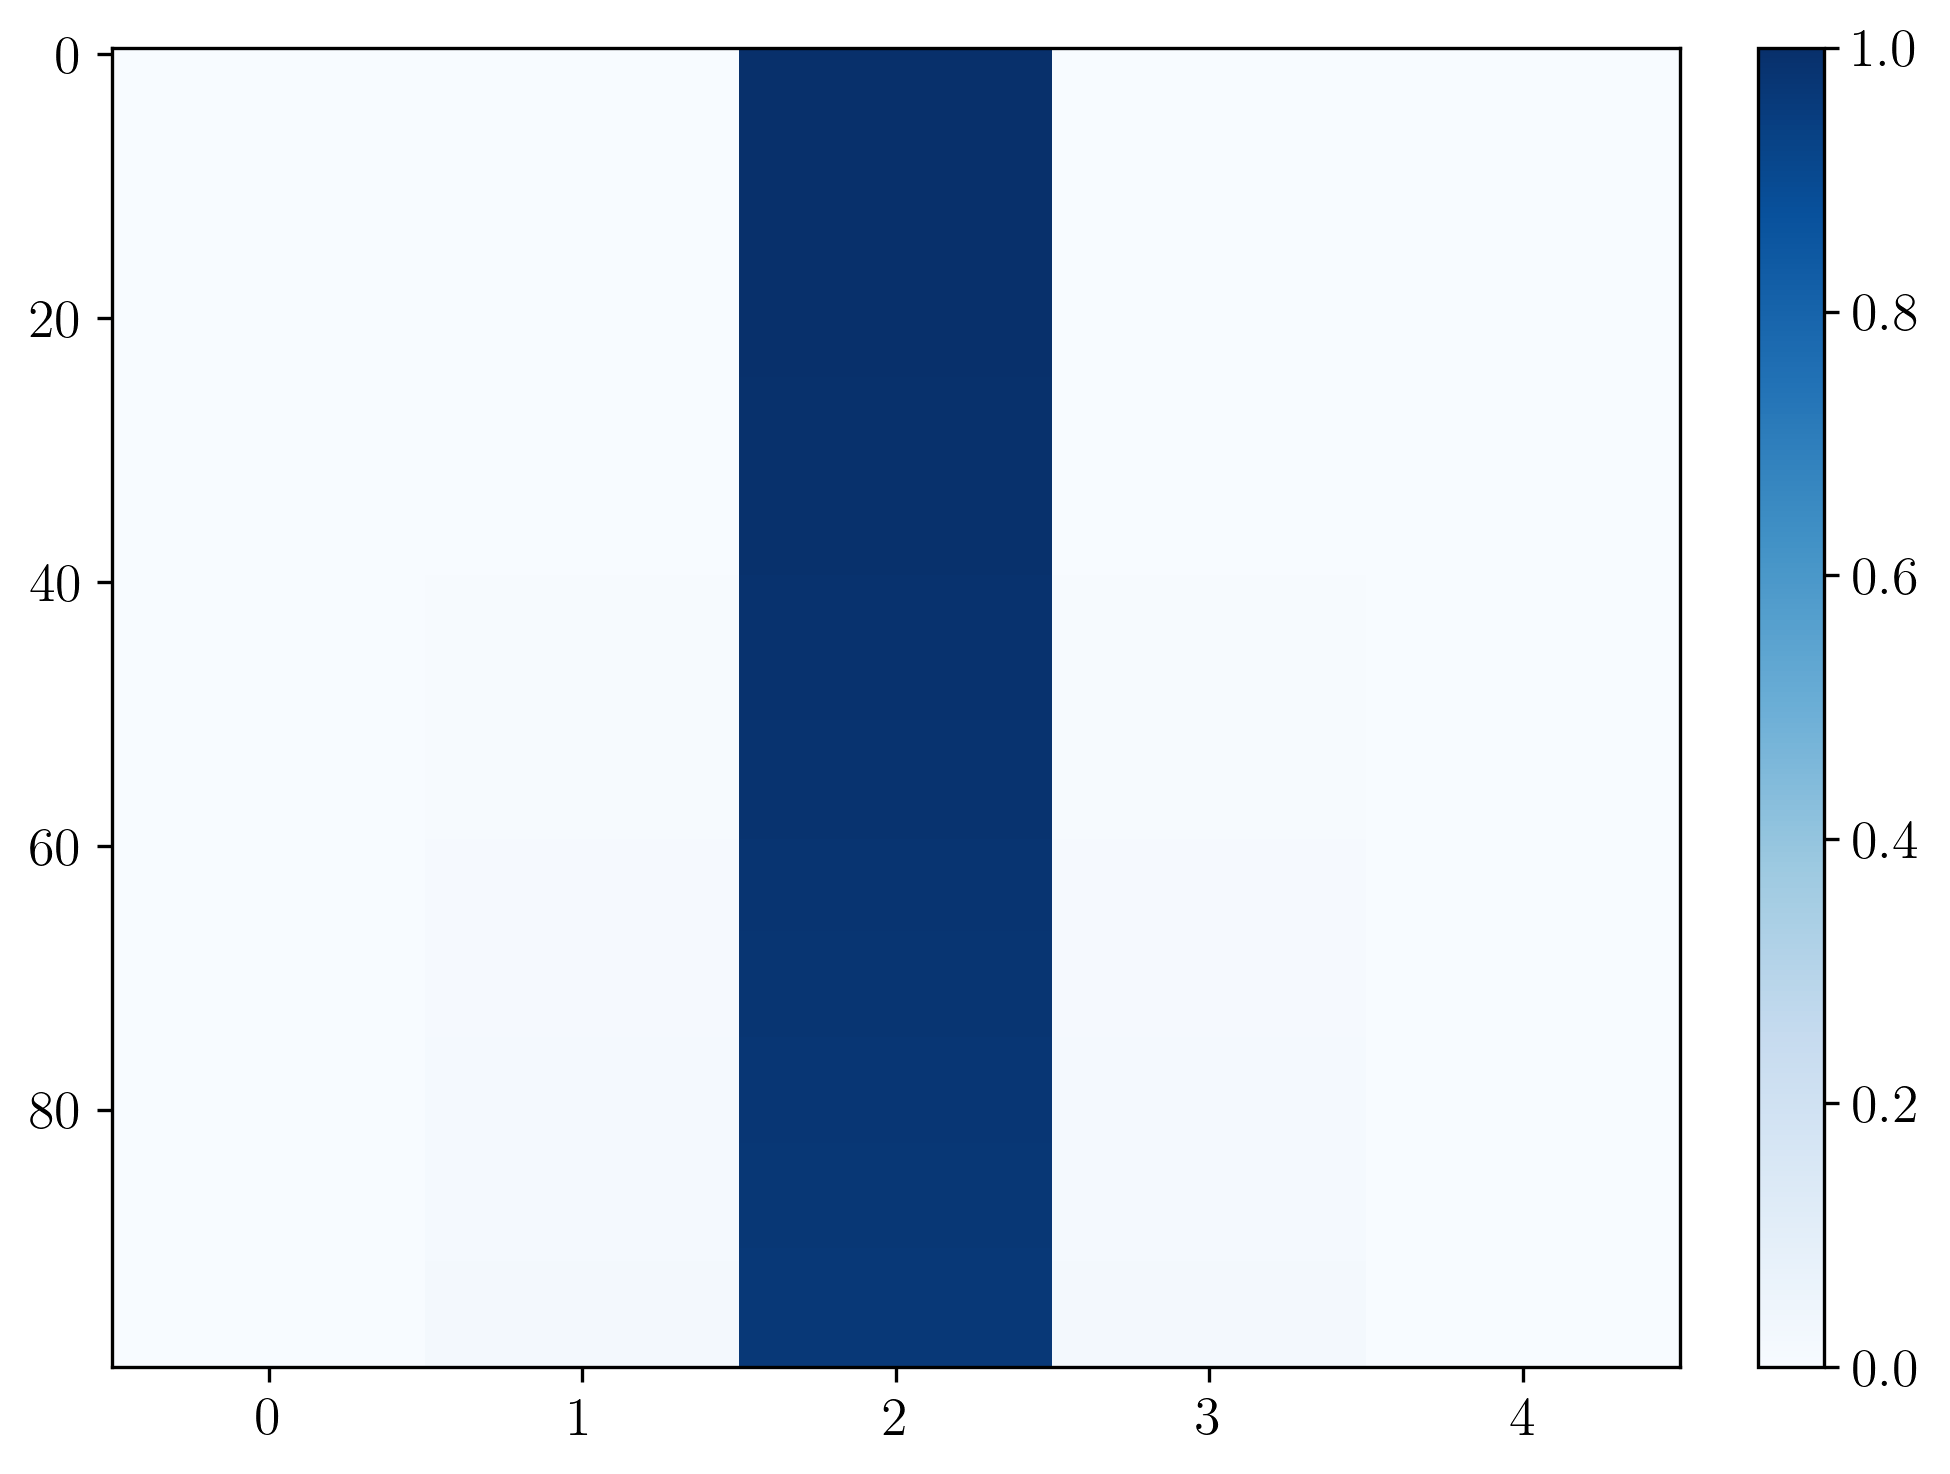

In [133]:
plt.imshow(np.asarray(occup_tot[0]), vmin=0, vmax=1, aspect='auto', cmap="Blues")
plt.colorbar()

## MPS

### test

In [216]:
half_chain_length = 2
t_up = 1
t_down = 1
Jz = 10
J_perp = 0
eps = 0
V = 0
trotter_steps = 100
final_time = 2

delta = trotter_steps/final_time

H_i_ip1 = Jz * kron(Sz, Sz) 
+ (J_perp/2) * kron(S_plus, S_minus)
+ (J_perp/2) * kron(S_minus, S_plus)
- (t_up) * kron(T_up_h, T_h_up)
- (t_up) * kron(T_h_up, T_up_h)
- (t_down) * kron(T_down_h, T_h_down)
- (t_down) * kron(T_h_down, T_down_h)

mat_ev_if = sp.linalg.expm(-1j * delta/2 * H_i_ip1.toarray())
mat_ev_bulk = sp.linalg.expm(-1j * delta * H_i_ip1.toarray())

In [217]:
op_ev_if = sp.linalg.expm(-1j * delta/2 * H_i_ip1.toarray())
op_ev_bulk = sp.linalg.expm(-1j * delta * H_i_ip1.toarray())

d = 3
schmidt_tol = 1e-15

# op_ev_if = np.swapaxes(op_ev_if, axis1=1, axis2=2)
original_matrix = op_ev_if
scaled_matrix = original_matrix / np.max(np.abs(original_matrix))
lambda_ = 1e-15
regularized_matrix = scaled_matrix + lambda_ * np.eye(
    scaled_matrix.shape[0], scaled_matrix.shape[1]
)

op_ev_if = op_ev_if.reshape(d,d,d,d)
# op_ev_if = op_ev_if.transpose(0,2,1,3)
op_ev_if = np.swapaxes(op_ev_if,2,1)
op_ev_if = op_ev_if.reshape(d*d,d*d)
u, s, v = svd(op_ev_if, full_matrices=False)

# print(s)
# condition = s >= schmidt_tol
# s_trunc = np.extract(condition, s)
# s = s_trunc / norm(s_trunc)

# print(s)

u = u[:, :len(s)]
site_i_if = u.reshape(d,d,len(s))
print(site_i_if.shape)
# site_i_if = site_i_if.transpose(2,0,1)
site_i_if = np.swapaxes(site_i_if, axis1=0, axis2=2)
print(site_i_if.shape)
site_i_if = np.swapaxes(site_i_if, axis1=1, axis2=2)
print(site_i_if.shape)
site_i_if = site_i_if[None,:,:,:]
print(site_i_if.shape)
# site_i_if = site_i_if.reshape(1,u.shape[1],d,d)
# site_i_if = site_i_if[:,:len(s),:,:]

print("\n---------")
v = v[:len(s),:]
site_ip1_if = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(len(s),d,d)
print(site_ip1_if.shape)
site_ip1_if = site_ip1_if[:,:,:,None]
print(site_ip1_if.shape)
site_ip1_if = site_ip1_if.transpose(0,3,1,2)
print(site_ip1_if.shape)
# site_ip1_if = site_ip1_if.reshape(1,v.shape[0],d,d)
# site_ip1_if = np.swapaxes(site_ip1_if, axis1=0, axis2=1)


# op_ev_bulk = op_ev_bulk.reshape(d,d,d,d)
# op_ev_bulk = np.swapaxes(op_ev_bulk, axis1=1, axis2=2)
# op_ev_bulk = op_ev_bulk.reshape(d*d,d*d)

op_ev_bulk = op_ev_bulk.reshape(d,d,d,d)
op_ev_bulk = op_ev_bulk.transpose(0,2,1,3)
op_ev_bulk = op_ev_bulk.reshape(d*d,d*d)

# original_matrix = op_ev_bulk
# scaled_matrix = original_matrix / np.max(np.abs(original_matrix))
# lambda_ = 1e-10
# regularized_matrix = scaled_matrix + lambda_ * np.eye(
#     scaled_matrix.shape[0], scaled_matrix.shape[1]
# )
u, s, v = svd(op_ev_bulk, full_matrices=False)

# print(s)
# condition = s >= schmidt_tol
# s_trunc = np.extract(condition, s)
# s = s_trunc / norm(s_trunc)

print(s)

u = u[:, :len(s)]
site_i_b = u.reshape(d,d,len(s))
print(site_i_b.shape)
site_i_b = site_i_b.transpose(2,0,1)
print(site_i_b.shape)
site_i_b = site_i_b[None,:,:,:]
print(site_i_b.shape)

# site_i_b = u.reshape(d,d,u.shape[1])
# site_i_b = np.swapaxes(site_i_b, axis1=2, axis2=0)
# site_i_b = site_i_b.reshape(1,u.shape[1],d,d)
# site_i_b = site_i_b[:,:len(s),:,:]

v = v[:len(s),:]
site_ip1_b = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(len(s),d,d)
print(site_ip1_b.shape)
site_ip1_b = site_ip1_b[:,:,:,None]
print(site_ip1_b.shape)
site_ip1_b = site_ip1_b.transpose(0,3,1,2)
print(site_ip1_b.shape)

# site_ip1_b = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(v.shape[0],d,d)
# site_ip1_b = site_ip1_b.reshape(1,v.shape[0],d,d)
# site_ip1_b = np.swapaxes(site_ip1_b, axis1=0, axis2=1)

(3, 3, 9)
(9, 3, 3)
(9, 3, 3)
(1, 9, 3, 3)

---------
(9, 3, 3)
(9, 3, 3, 1)
(9, 1, 3, 3)
[2.73089837e+00 1.23208092e+00 1.55469343e-01 3.82453817e-17
 6.22012615e-33 5.93749578e-34 0.00000000e+00 0.00000000e+00
 0.00000000e+00]
(3, 3, 9)
(9, 3, 3)
(1, 9, 3, 3)
(9, 3, 3)
(9, 3, 3, 1)
(9, 1, 3, 3)


In [218]:
op_rec_if = ncon([site_i_if,site_ip1_if],[[-1,1,-3,-5],[1,-2,-4,-6]]).reshape((1,1,d*d,d*d))
mat_rec_if = op_rec_if[0,0,:,:]
print(mat_rec_if.shape)
i = 4
mat_rec_if[i], mat_ev_if[i]

(9, 9)


(array([-2.44348554e-034+9.34930118e-035j,
        -2.67964888e-050+8.01868925e-051j,
        -2.31968254e-082-1.26186174e-082j,
        -2.31840957e-048+6.69637346e-049j,
         1.00000000e+000+3.36722052e-017j,
         5.71732905e-101-2.38842526e-099j,
         1.16747705e-082-6.11169062e-083j,
         1.33661083e-113-1.52611618e-113j,
         2.19258302e-067-1.16651898e-066j]),
 array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
        0.+0.j]))

In [229]:
mpo_start_left = site_i_if.copy()
mpo_start_bulk_1 = ncon([site_ip1_if, site_i_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip1_if.shape[0]*site_i_b.shape[0],site_ip1_if.shape[1]*site_i_b.shape[1],site_ip1_if.shape[2], site_i_b.shape[3]))
mpo_start_bulk_2 = ncon([site_i_if, site_ip1_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_i_if.shape[0]*site_ip1_b.shape[0],site_i_if.shape[1]*site_ip1_b.shape[1],site_i_if.shape[2], site_ip1_b.shape[3]))
mpo_start_right_1 = site_ip1_b.copy() # for odd chains
mpo_start_right_2 = site_ip1_if.copy() # for even chains


def evolution_mpo_start_tJ(n):
    mpo_start_left = site_i_if.copy()
    mpo_start_bulk_1 = ncon([site_ip1_if, site_i_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip1_if.shape[0]*site_i_b.shape[0],site_ip1_if.shape[1]*site_i_b.shape[1],site_ip1_if.shape[2], site_i_b.shape[3]))
    mpo_start_bulk_2 = ncon([site_i_if, site_ip1_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_i_if.shape[0]*site_ip1_b.shape[0],site_i_if.shape[1]*site_ip1_b.shape[1],site_i_if.shape[2], site_ip1_b.shape[3]))
    mpo_start_right_1 = site_ip1_b.copy() # for odd chains
    mpo_start_right_2 = site_ip1_if.copy() # for even chains

    mpo_start = []
    mpo_start.append(mpo_start_left)
    for i in range(1,n-1):
        if (i%2) == 0:
            mpo_start.append(mpo_start_bulk_2)
        elif (i%2) == 1:
            mpo_start.append(mpo_start_bulk_1)
    
    if (n%2) == 0:
        mpo_start.append(mpo_start_right_2)
    elif (n%2) == 1:
        mpo_start.append(mpo_start_right_1)
    
    return mpo_start

def evolution_mpo_step_tJ(n):
    mpo_step_left = ncon([site_i_if,site_i_if],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_i_if.shape[0]**2,site_i_if.shape[1]**2,d,d))
    mpo_step_bulk_odd = ncon([site_ip1_if, site_i_b, site_ip1_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_ip1_if.shape[0]*site_i_b.shape[0]*site_ip1_if.shape[0],site_ip1_if.shape[1]*site_i_b.shape[1]*site_ip1_if.shape[1],d,d))
    mpo_step_bulk_even = ncon([site_i_if, site_ip1_b, site_i_if],[[-1,-4,-7,1],[-2,-5,1,2],[-3,-6,2,-8]]).reshape((site_i_if.shape[0]*site_ip1_b.shape[0]*site_i_if.shape[0],site_i_if.shape[1]*site_ip1_b.shape[1]*site_i_if.shape[1],d,d))
    mpo_step_right_1 = site_ip1_b.copy() # for odd chains
    mpo_step_right_2 = ncon([site_ip1_if,site_ip1_if],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip1_if.shape[0]**2,site_ip1_if.shape[1]**2,d,d)) # for even chains

    mpo_step = []
    mpo_step.append(mpo_step_left)
    for i in range(1,n-1):
        if (i%2) == 0:
            mpo_step.append(mpo_step_bulk_even)
        elif (i%2) == 1:
            mpo_step.append(mpo_step_bulk_odd)
    
    if (n%2) == 0:
        mpo_step.append(mpo_step_right_2)
    elif (n%2) == 1:
        mpo_step.append(mpo_step_right_1)
    
    return mpo_step

def evolution_mpo_ev_tJ(n):
    mpo_ev_left = site_i_b.copy()
    mpo_ev_bulk_1 = ncon([site_ip1_b, site_i_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip1_b.shape[0]*site_i_b.shape[0],site_ip1_b.shape[1]*site_i_b.shape[1],site_ip1_b.shape[2], site_i_b.shape[3]))
    mpo_ev_bulk_2 = ncon([site_i_b, site_ip1_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_i_b.shape[0]*site_ip1_b.shape[0],site_i_b.shape[1]*site_ip1_b.shape[1],site_i_b.shape[2], site_ip1_b.shape[3]))
    mpo_ev_right = site_ip1_b.copy()

    mpo_ev = []
    mpo_ev.append(mpo_ev_left)
    for i in range(1,n-1):
        if (i%2) == 0:
            mpo_ev.append(mpo_ev_bulk_2)
        elif (i%2) == 1:
            mpo_ev.append(mpo_ev_bulk_1)

    mpo_ev.append(mpo_ev_right)
    
    return mpo_ev

def evolution_mpo_end_tJ(n):
    mpo_end_even = site_i_if.copy()
    mpo_end_odd = site_ip1_if.copy()
    mpo_end = []
    for i in range(n-1):
        if (i%2) == 0:
            mpo_end.append(mpo_end_even)
        elif (i%2) == 1:
            mpo_end.append(mpo_end_odd)
    
    if (n%2) == 0:
        mpo_end.append(mpo_end_odd)
    elif (n%2) == 1:
        mpo_end.append(Id.reshape((1,1,3,3)))
    
    return mpo_end

In [233]:
n = 5
mpo_start = evolution_mpo_start_tJ(n)
mpo_ev = evolution_mpo_ev_tJ(n)
mpo_end = evolution_mpo_end_tJ(n)
mpo_step = evolution_mpo_step_tJ(n)
tensor_shapes(mpo_step)

(1, 9, 3, 3)
(9, 3, 3, 3)
(3, 9, 3, 3)
(9, 3, 3, 3)
(3, 1, 3, 3)


[(1, 9, 3, 3), (9, 3, 3, 3), (3, 9, 3, 3), (9, 3, 3, 3), (3, 1, 3, 3)]

In [235]:
U_start = mpo_to_matrix(mpo_start)
U_ev = mpo_to_matrix(mpo_ev)
U_end = mpo_to_matrix(mpo_end)
U_step = mpo_to_matrix(mpo_step)

In [236]:
def U_i_ip1_tJ(Jz, t_up, t_down, J_perp, delta):
    """
    U_i_ip1

    This function computes the exponential of the 2-site hamiltonian for the t-J model.
    It returns to versions: 
    1. one with a time step delta/2 to use at the initial and final step
    of the trotterization
    2. one with a time step delta to use in the bulk steps of the trotterization

    """

    # choose the hamiltonian parameters
    H_i_ip1 = Jz * kron(Sz, Sz) 
    + (J_perp/2) * kron(S_plus, S_minus) 
    + (J_perp/2) * kron(S_minus, S_plus) 
    - (t_up) * kron(T_up_h, T_h_up) 
    - (t_up) * kron(T_h_up, T_up_h) 
    - (t_down) * kron(T_down_h, T_h_down) 
    - (t_down) * kron(T_h_down, T_down_h)

    # initial and final 2-site evolution operator
    op_ev_if = sp.linalg.expm(-1j * delta/2 * H_i_ip1.toarray())

    # bulk 2-site evolution operator
    op_ev_bulk = sp.linalg.expm(-1j * delta * H_i_ip1.toarray())
    
    return op_ev_if, op_ev_bulk

def evolution_mpo_svd_tJ(op_ev_if: np.ndarray, op_ev_bulk: np.ndarray, d: int=3, schmidt_tol: float=1e-15):
    """
    evolution_mpo_svd

    This function takes the edges, and bulk 2-site evolution operators (of the t-J model) and performs an svd
    to separate the matrix into site i and site i+1. Reshaping the results of the svd
    we can obtain the mpo for those evolution operators (with bounded bond dimension D<=d^2)

    """
    op_ev_if = op_ev_if.reshape(d,d,d,d)
    op_ev_if = op_ev_if.transpose(0,2,1,3)
    op_ev_if = op_ev_if.reshape(d*d,d*d)

    u, s, v = svd(op_ev_if, full_matrices=False)

    condition = s >= schmidt_tol
    s_trunc = np.extract(condition, s)
    s = s_trunc
    v = v[:len(s),:]

    site_i_if = u.reshape(d,d,u.shape[1])
    site_i_if = site_i_if[:, :, :len(s)]
    site_i_if = site_i_if.transpose(2,0,1)
    site_i_if = site_i_if.reshape(1,len(s),d,d)

    site_ip1_if = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(v.shape[0],d,d)
    site_ip1_if = site_ip1_if.reshape(1,v.shape[0],d,d)
    site_ip1_if = site_ip1_if.transpose(1,0,2,3)


    op_ev_bulk = op_ev_bulk.reshape(d,d,d,d)
    op_ev_bulk = op_ev_bulk.transpose(0,2,1,3)
    op_ev_bulk = op_ev_bulk.reshape(d*d,d*d)

    u, s, v = svd(op_ev_bulk, full_matrices=False)

    condition = s >= schmidt_tol
    s_trunc = np.extract(condition, s)
    s = s_trunc
    v = v[:len(s),:]

    site_i_b = u.reshape(d,d,u.shape[1])
    site_i_b = site_i_b[:, :, :len(s)]
    site_i_b = site_i_b.transpose(2,0,1)
    site_i_b = site_i_b.reshape(1,len(s),d,d)

    site_ip1_b = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(v.shape[0],d,d)
    site_ip1_b = site_ip1_b.reshape(1,v.shape[0],d,d)
    site_ip1_b = site_ip1_b.transpose(1,0,2,3)

    tol = 1e-15 * np.max(np.abs(site_i_if))
    site_i_if.real[np.abs(site_i_if.real) < tol] = 0
    site_i_if.imag[np.abs(site_i_if.imag) < tol] = 0
    
    tol = 1e-15 * np.max(np.abs(site_ip1_if))
    site_ip1_if.real[np.abs(site_ip1_if.real) < tol] = 0
    site_ip1_if.imag[np.abs(site_ip1_if.imag) < tol] = 0
    
    tol = 1e-15 * np.max(np.abs(site_i_b))
    site_i_b.real[np.abs(site_i_b.real) < tol] = 0
    site_i_b.imag[np.abs(site_i_b.imag) < tol] = 0
    
    tol = 1e-15 * np.max(np.abs(site_ip1_b))
    site_ip1_b.real[np.abs(site_ip1_b.real) < tol] = 0
    site_ip1_b.imag[np.abs(site_ip1_b.imag) < tol] = 0

    return site_i_if, site_ip1_if, site_i_b, site_ip1_b

def evolution_mpo_start_tJ(n, site_i_if, site_ip1_if, site_i_b, site_ip1_b):
    """
    evolution_mpo_start_tJ

    This function finds the starting evolution mpo for a chain n of the t-J model.
    It is the first step of a second order trotterization.

    """
    # first site has one tensor only
    mpo_start_left = site_i_if.copy()
    # two bulk operators for even and odd sites
    mpo_start_bulk_odd = ncon([site_ip1_if, site_i_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip1_if.shape[0]*site_i_b.shape[0],site_ip1_if.shape[1]*site_i_b.shape[1],site_ip1_if.shape[2], site_i_b.shape[3]))
    mpo_start_bulk_even = ncon([site_i_if, site_ip1_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_i_if.shape[0]*site_ip1_b.shape[0],site_i_if.shape[1]*site_ip1_b.shape[1],site_i_if.shape[2], site_ip1_b.shape[3]))
    # two last-site operators depending on the parity of the chain
    mpo_start_right_b = site_ip1_b.copy() # for odd chains
    mpo_start_right_if = site_ip1_if.copy() # for even chains

    mpo_start = []
    
    # left op
    mpo_start.append(mpo_start_left)
    
    # bulk ops
    for i in range(1,n-1):
        if (i%2) == 0:
            mpo_start.append(mpo_start_bulk_even)
        elif (i%2) == 1:
            mpo_start.append(mpo_start_bulk_odd)
    
    # right op
    if (n%2) == 0:
        mpo_start.append(mpo_start_right_if)
    elif (n%2) == 1:
        mpo_start.append(mpo_start_right_b)
    
    return mpo_start

def evolution_mpo_ev_tJ(n, site_i_b, site_ip1_b):
    """
    evolution_mpo_ev_tJ

    This function finds the bulk evolution mpo for a chain n of the t-J model.
    The mpo found can be used in all the steps of a second order trotterization
    after the starting step and before the last step.

    """
    # first site has one tensor only
    mpo_ev_left = site_i_b.copy()
    # two bulk operators for even and odd sites
    mpo_ev_bulk_odd = ncon([site_ip1_b, site_i_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_ip1_b.shape[0]*site_i_b.shape[0],site_ip1_b.shape[1]*site_i_b.shape[1],site_ip1_b.shape[2], site_i_b.shape[3]))
    mpo_ev_bulk_even = ncon([site_i_b, site_ip1_b],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((site_i_b.shape[0]*site_ip1_b.shape[0],site_i_b.shape[1]*site_ip1_b.shape[1],site_i_b.shape[2], site_ip1_b.shape[3]))
    # last site has one tensor only
    mpo_ev_right = site_ip1_b.copy()

    mpo_ev = []
    
    # left op
    mpo_ev.append(mpo_ev_left)
    
    # bulk ops
    for i in range(1,n-1):
        if (i%2) == 0:
            mpo_ev.append(mpo_ev_bulk_even)
        elif (i%2) == 1:
            mpo_ev.append(mpo_ev_bulk_odd)

    # right op
    mpo_ev.append(mpo_ev_right)
    
    return mpo_ev

def evolution_mpo_end_tJ(n, site_i_if, site_ip1_if):
    """
    evolution_mpo_end_tJ

    This function finds the ending evolution mpo for a chain n of the t-J model.
    It is the last step of a second order trotterization.

    """
    # both even and odd sites have one tensor only
    mpo_end_even = site_i_if.copy()
    mpo_end_odd = site_ip1_if.copy()

    mpo_end = []
    
    # bulk ops
    for i in range(n-1):
        if (i%2) == 0:
            mpo_end.append(mpo_end_even)
        elif (i%2) == 1:
            mpo_end.append(mpo_end_odd)
    
    # right op
    if (n%2) == 0:
        mpo_end.append(mpo_end_odd)
    elif (n%2) == 1:
        mpo_end.append(Id.reshape((1,1,3,3)))
    
    return mpo_end


In [237]:
half_chain_length = 2
t_up = 2
t_down = 2
Jz = 10
J_perp = 0
eps = 0
V = 0
trotter_steps = 100
final_time = 2
delta = final_time / trotter_steps

In [238]:
spin_up = np.array([1,0,0])
hole = np.array([0,1,0])
spin_down = np.array([0,0,1])

# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = psi_init.reshape((3**(2*half_chain_length + 2)))

n = 2*half_chain_length + 1

op_ev_if, op_ev_bulk = U_i_ip1_tJ(Jz, t_up, t_down, J_perp, delta)
site_i_if, site_ip1_if, site_i_b, site_ip1_b = evolution_mpo_svd_tJ(op_ev_if, op_ev_bulk)

mpo_start = evolution_mpo_start_tJ(n, site_i_if, site_ip1_if, site_i_b, site_ip1_b)
mpo_ev = evolution_mpo_ev_tJ(n, site_i_b, site_ip1_b)
mpo_end = evolution_mpo_end_tJ(n, site_i_if, site_ip1_if)

U_start = mpo_to_matrix(mpo_start)
U_ev = mpo_to_matrix(mpo_ev)
U_end = mpo_to_matrix(mpo_end)

In [239]:
tensor_shapes(mpo_start)

(1, 3, 3, 3)
(3, 3, 3, 3)
(3, 3, 3, 3)
(3, 3, 3, 3)
(3, 1, 3, 3)


[(1, 3, 3, 3), (3, 3, 3, 3), (3, 3, 3, 3), (3, 3, 3, 3), (3, 1, 3, 3)]

In [240]:
H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, n_holes=1)

psi_ev = psi_init.copy()

obs = ['h_loc', 'm_loc']
ops_h = local_hole_occupation(n)
ops_m = local_mag_occupation(n)

occup_tot_h = []
occup_tot_m = []
fidelity = []

psi_ev = U_start @ psi_ev

if 'h_loc' in obs:
    occup = []
    for op in ops_h:
        occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
        # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
    occup_tot_h.append(occup)


if 'm_loc' in obs:
    occup = []
    for op in ops_m:
        occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
        # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
    occup_tot_m.append(occup)

fidelity.append(abs(psi_ev @ psi_save[0]))

for t in range(trotter_steps-1):
    print(f"trotter step: {t}")
    
    psi_ev = U_ev @ psi_ev

    if 'h_loc' in obs:
        occup = []
        for op in ops_h:
            occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
            # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
        occup_tot_h.append(occup)

    if 'm_loc' in obs:
        occup = []
        for op in ops_m:
            occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
            # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
        occup_tot_m.append(occup)
    
    fidelity.append(abs(psi_ev @ psi_save[t+1]))

psi_ev = U_end @ psi_ev

if 'h_loc' in obs:
    occup = []
    for op in ops_h:
        occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
        # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
    occup_tot_h.append(occup)

if 'm_loc' in obs:
    occup = []
    for op in ops_m:
        occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
        # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
    occup_tot_m.append(occup)

fidelity.append(abs(psi_ev @ psi_save[-1]))



trotter step: 0
trotter step: 1
trotter step: 2
trotter step: 3
trotter step: 4
trotter step: 5
trotter step: 6
trotter step: 7
trotter step: 8
trotter step: 9
trotter step: 10
trotter step: 11
trotter step: 12
trotter step: 13
trotter step: 14
trotter step: 15
trotter step: 16
trotter step: 17
trotter step: 18
trotter step: 19
trotter step: 20
trotter step: 21
trotter step: 22
trotter step: 23
trotter step: 24
trotter step: 25
trotter step: 26
trotter step: 27
trotter step: 28
trotter step: 29
trotter step: 30
trotter step: 31
trotter step: 32
trotter step: 33
trotter step: 34
trotter step: 35
trotter step: 36
trotter step: 37
trotter step: 38
trotter step: 39
trotter step: 40
trotter step: 41
trotter step: 42
trotter step: 43
trotter step: 44
trotter step: 45
trotter step: 46
trotter step: 47
trotter step: 48
trotter step: 49
trotter step: 50
trotter step: 51
trotter step: 52
trotter step: 53
trotter step: 54
trotter step: 55
trotter step: 56
trotter step: 57
trotter step: 58
trotter

In [246]:
U_step.shape, psi_ev.shape, psi_init.shape, type(U_step)

((243, 243), (243,), (243,), numpy.ndarray)

In [247]:

H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, n_holes=1)

psi_ev = psi_init.copy()

obs = ['h_loc', 'm_loc']
ops_h = local_hole_occupation(n)
ops_m = local_mag_occupation(n)

occup_tot_h = []
occup_tot_m = []
fidelity = []

for t in range(trotter_steps):
    print(f"trotter step: {t}")
    
    psi_ev = U_step @ psi_ev

    if 'h_loc' in obs:
        occup = []
        for op in ops_h:
            occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
            # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
        occup_tot_h.append(occup)

    if 'm_loc' in obs:
        occup = []
        for op in ops_m:
            occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
            # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
        occup_tot_m.append(occup)
    
    fidelity.append(abs(psi_ev @ psi_save[t]))


trotter step: 0
trotter step: 1
trotter step: 2
trotter step: 3
trotter step: 4
trotter step: 5
trotter step: 6
trotter step: 7
trotter step: 8
trotter step: 9
trotter step: 10
trotter step: 11
trotter step: 12
trotter step: 13
trotter step: 14
trotter step: 15
trotter step: 16
trotter step: 17
trotter step: 18
trotter step: 19
trotter step: 20
trotter step: 21
trotter step: 22
trotter step: 23
trotter step: 24
trotter step: 25
trotter step: 26
trotter step: 27
trotter step: 28
trotter step: 29
trotter step: 30
trotter step: 31
trotter step: 32
trotter step: 33
trotter step: 34
trotter step: 35
trotter step: 36
trotter step: 37
trotter step: 38
trotter step: 39
trotter step: 40
trotter step: 41
trotter step: 42
trotter step: 43
trotter step: 44
trotter step: 45
trotter step: 46
trotter step: 47
trotter step: 48
trotter step: 49
trotter step: 50
trotter step: 51
trotter step: 52
trotter step: 53
trotter step: 54
trotter step: 55
trotter step: 56
trotter step: 57
trotter step: 58
trotter

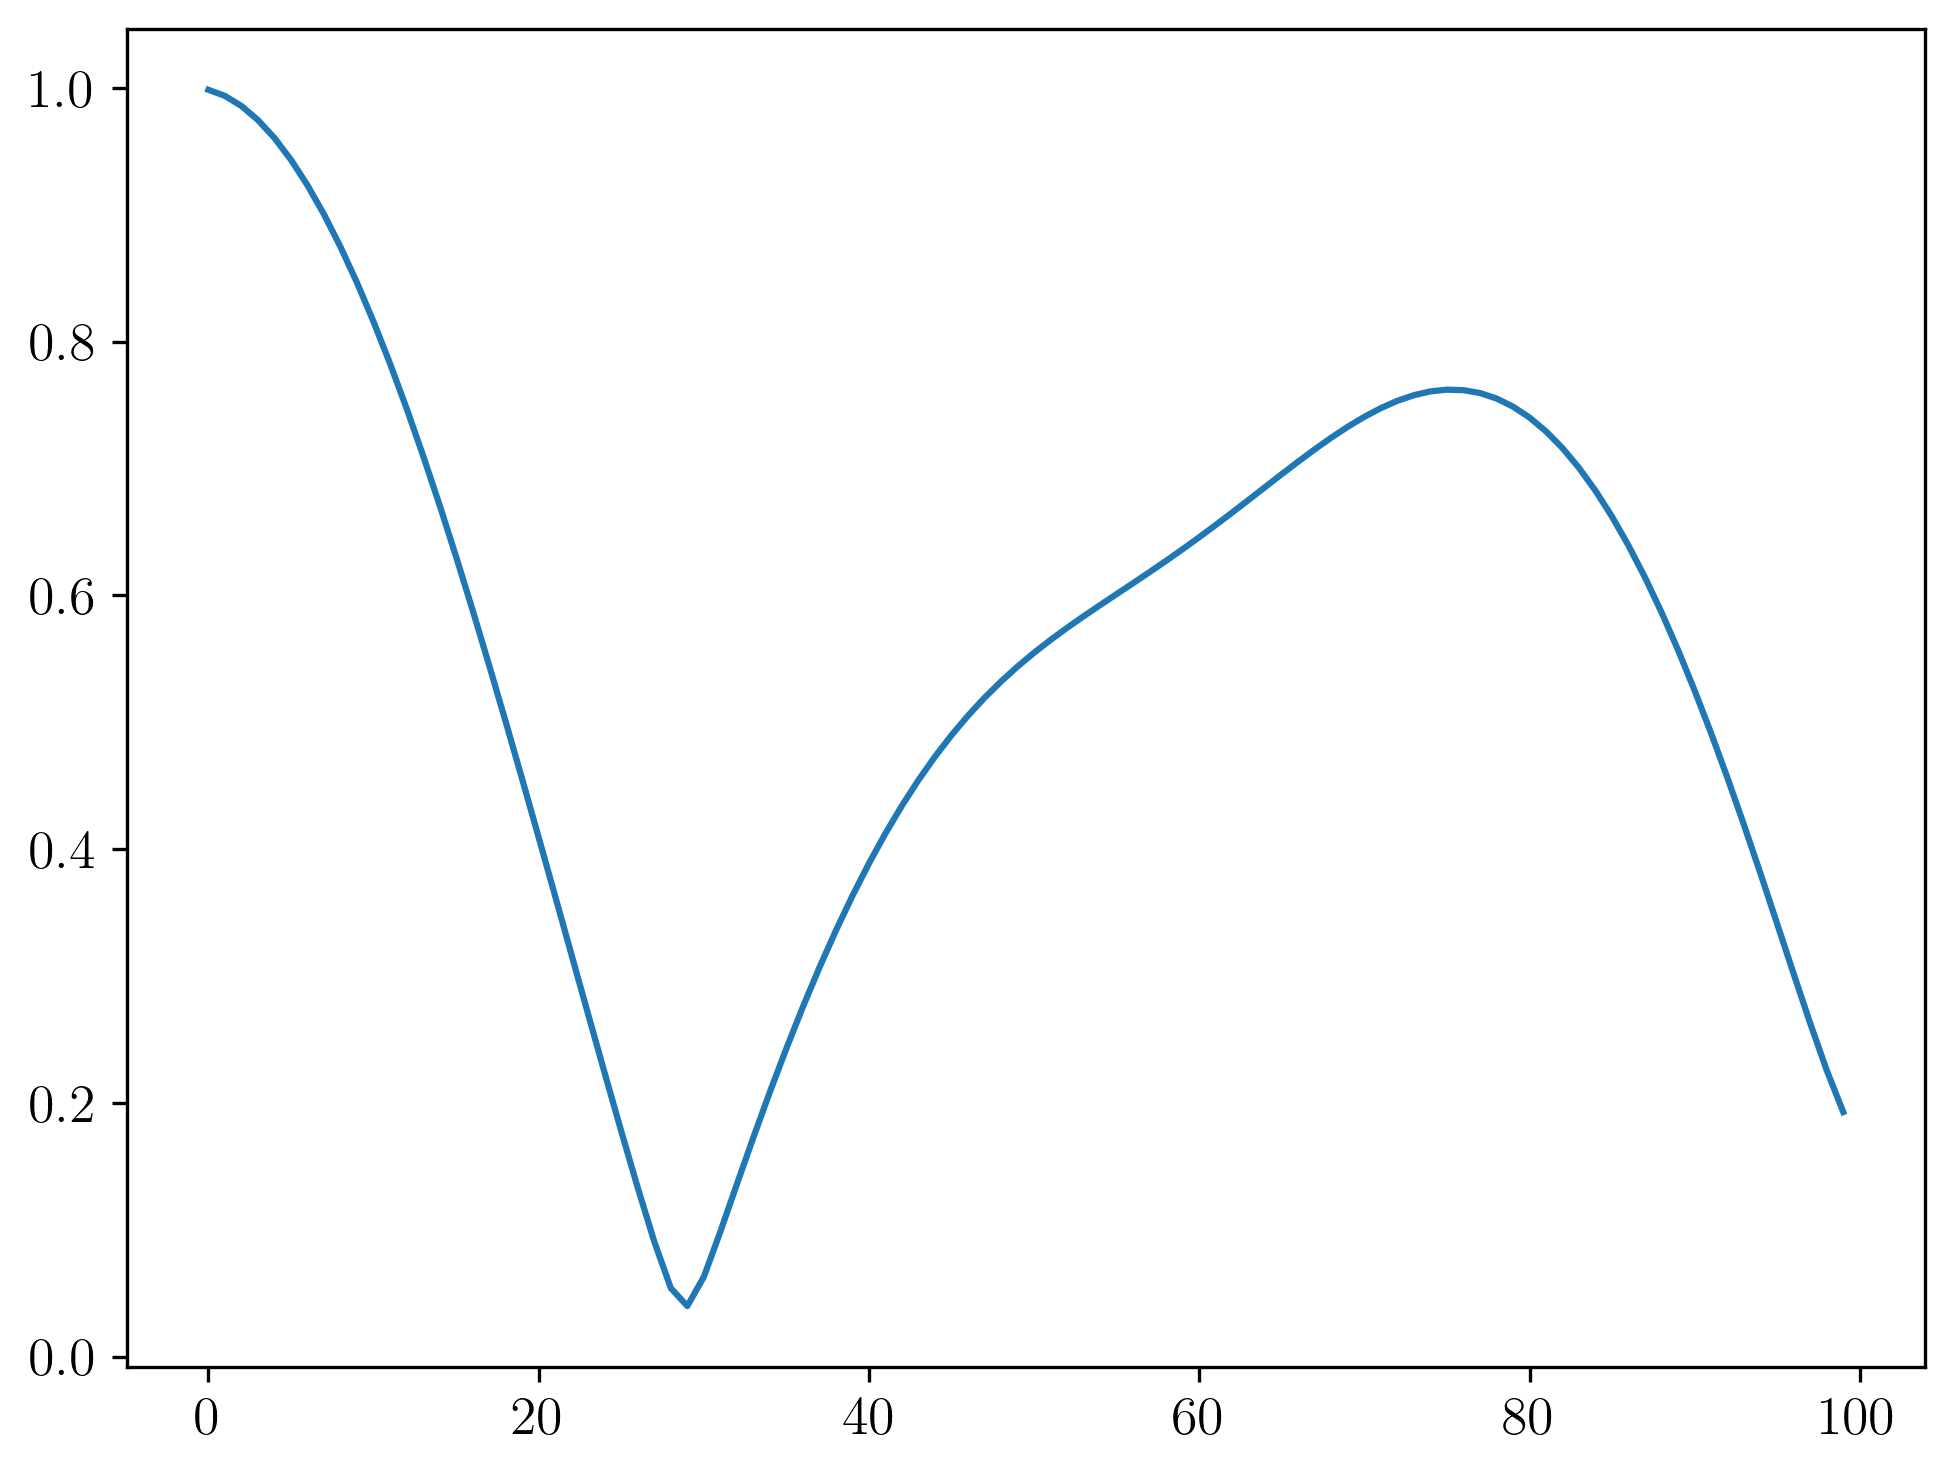

In [248]:
plt.plot(fidelity)

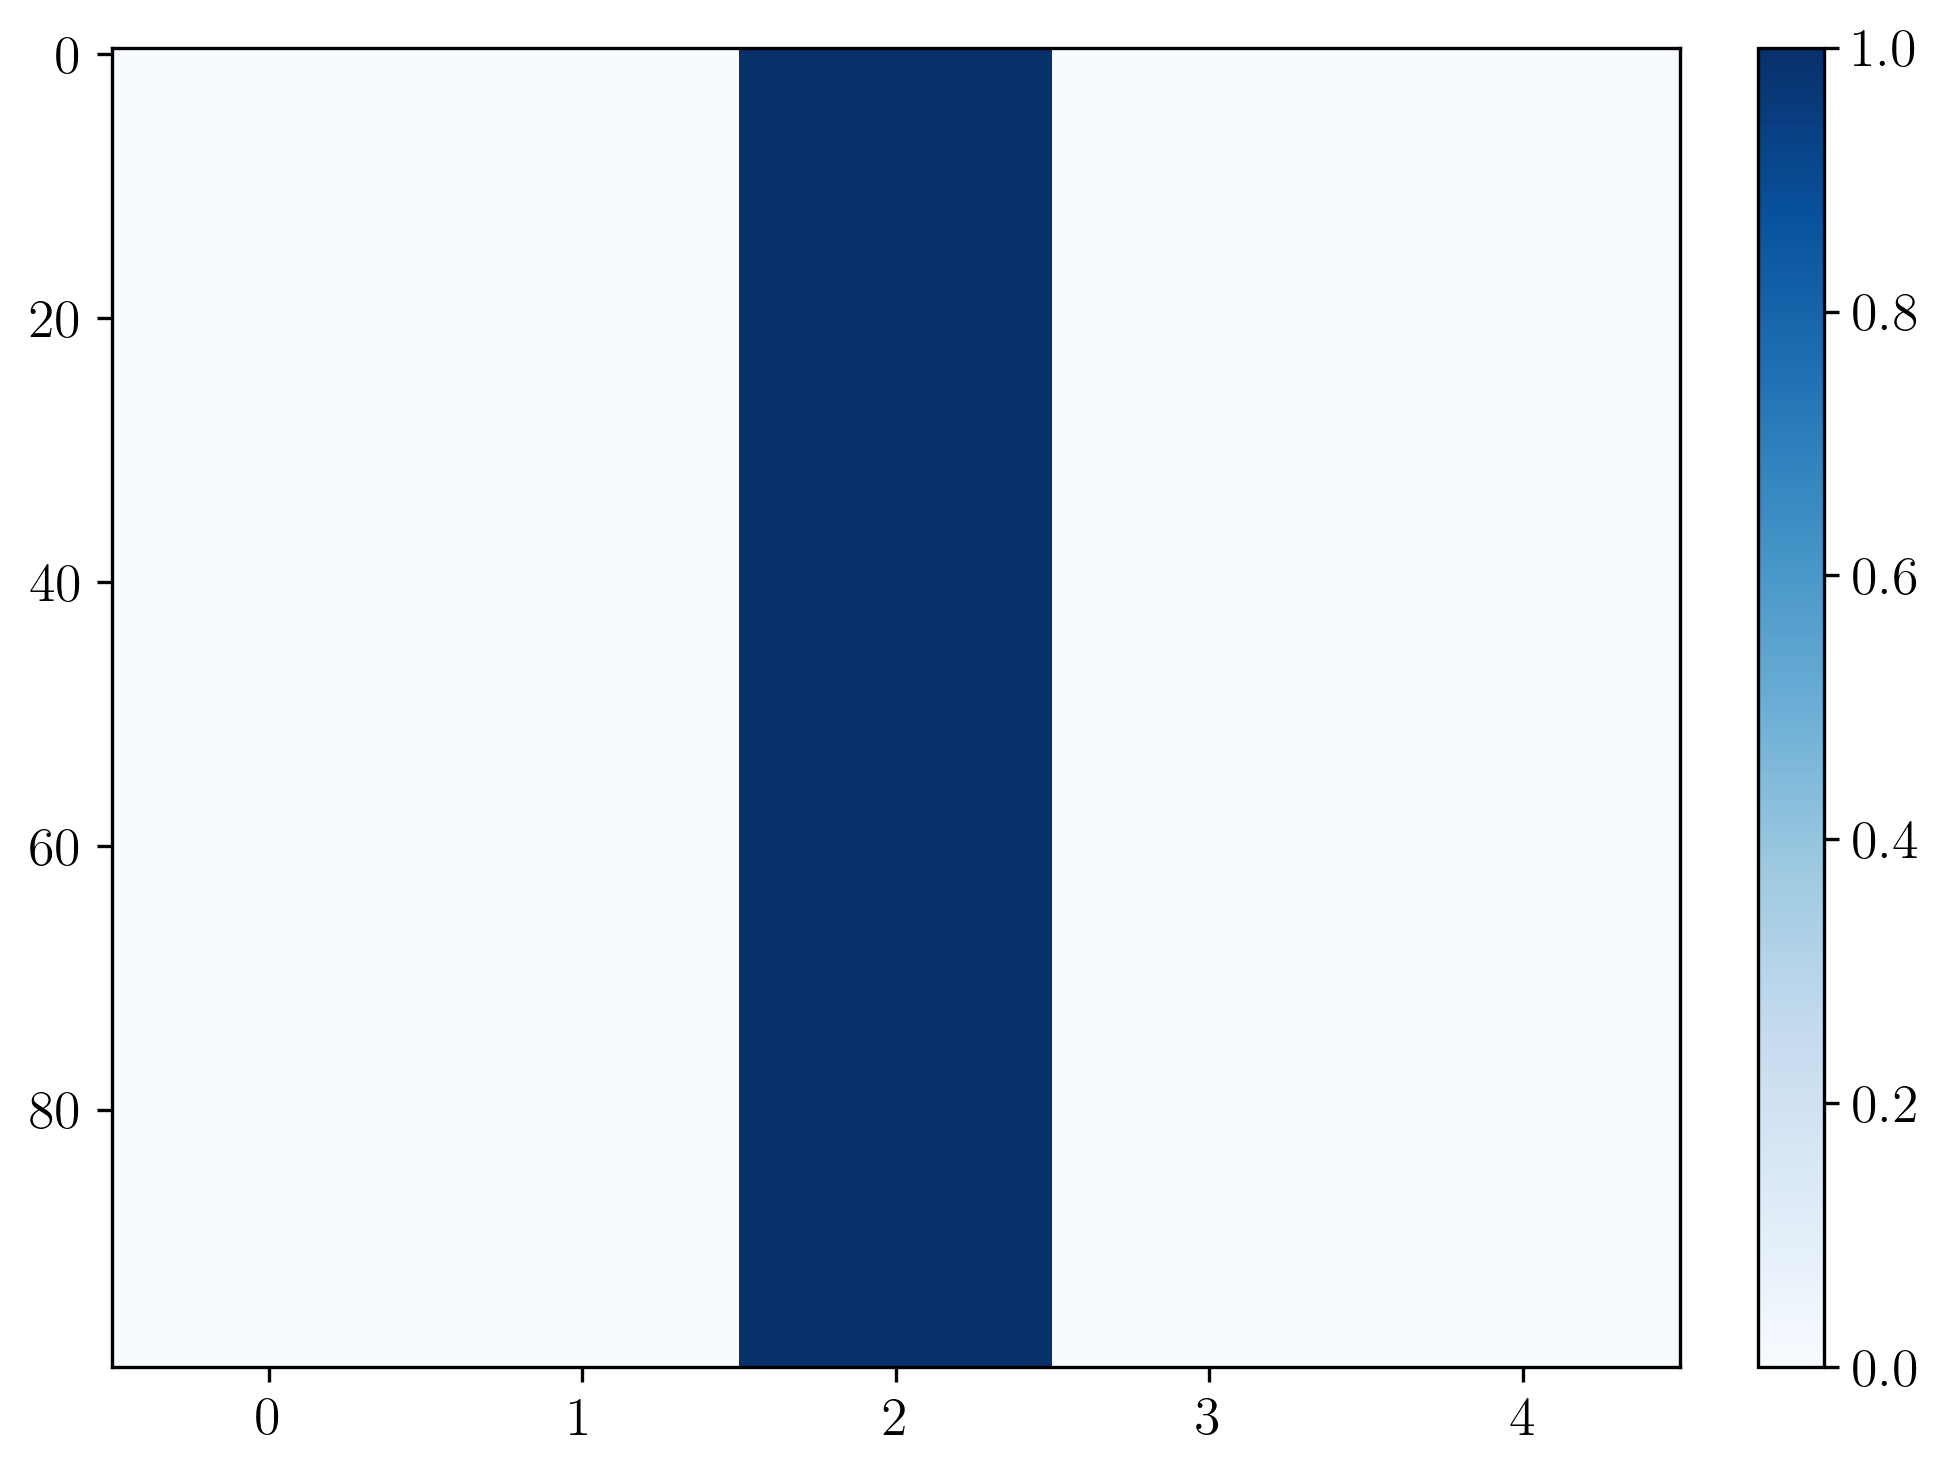

In [249]:
plt.imshow(np.asarray(occup_tot_h), vmin=0, vmax=1, aspect='auto', cmap="Blues")
plt.colorbar()

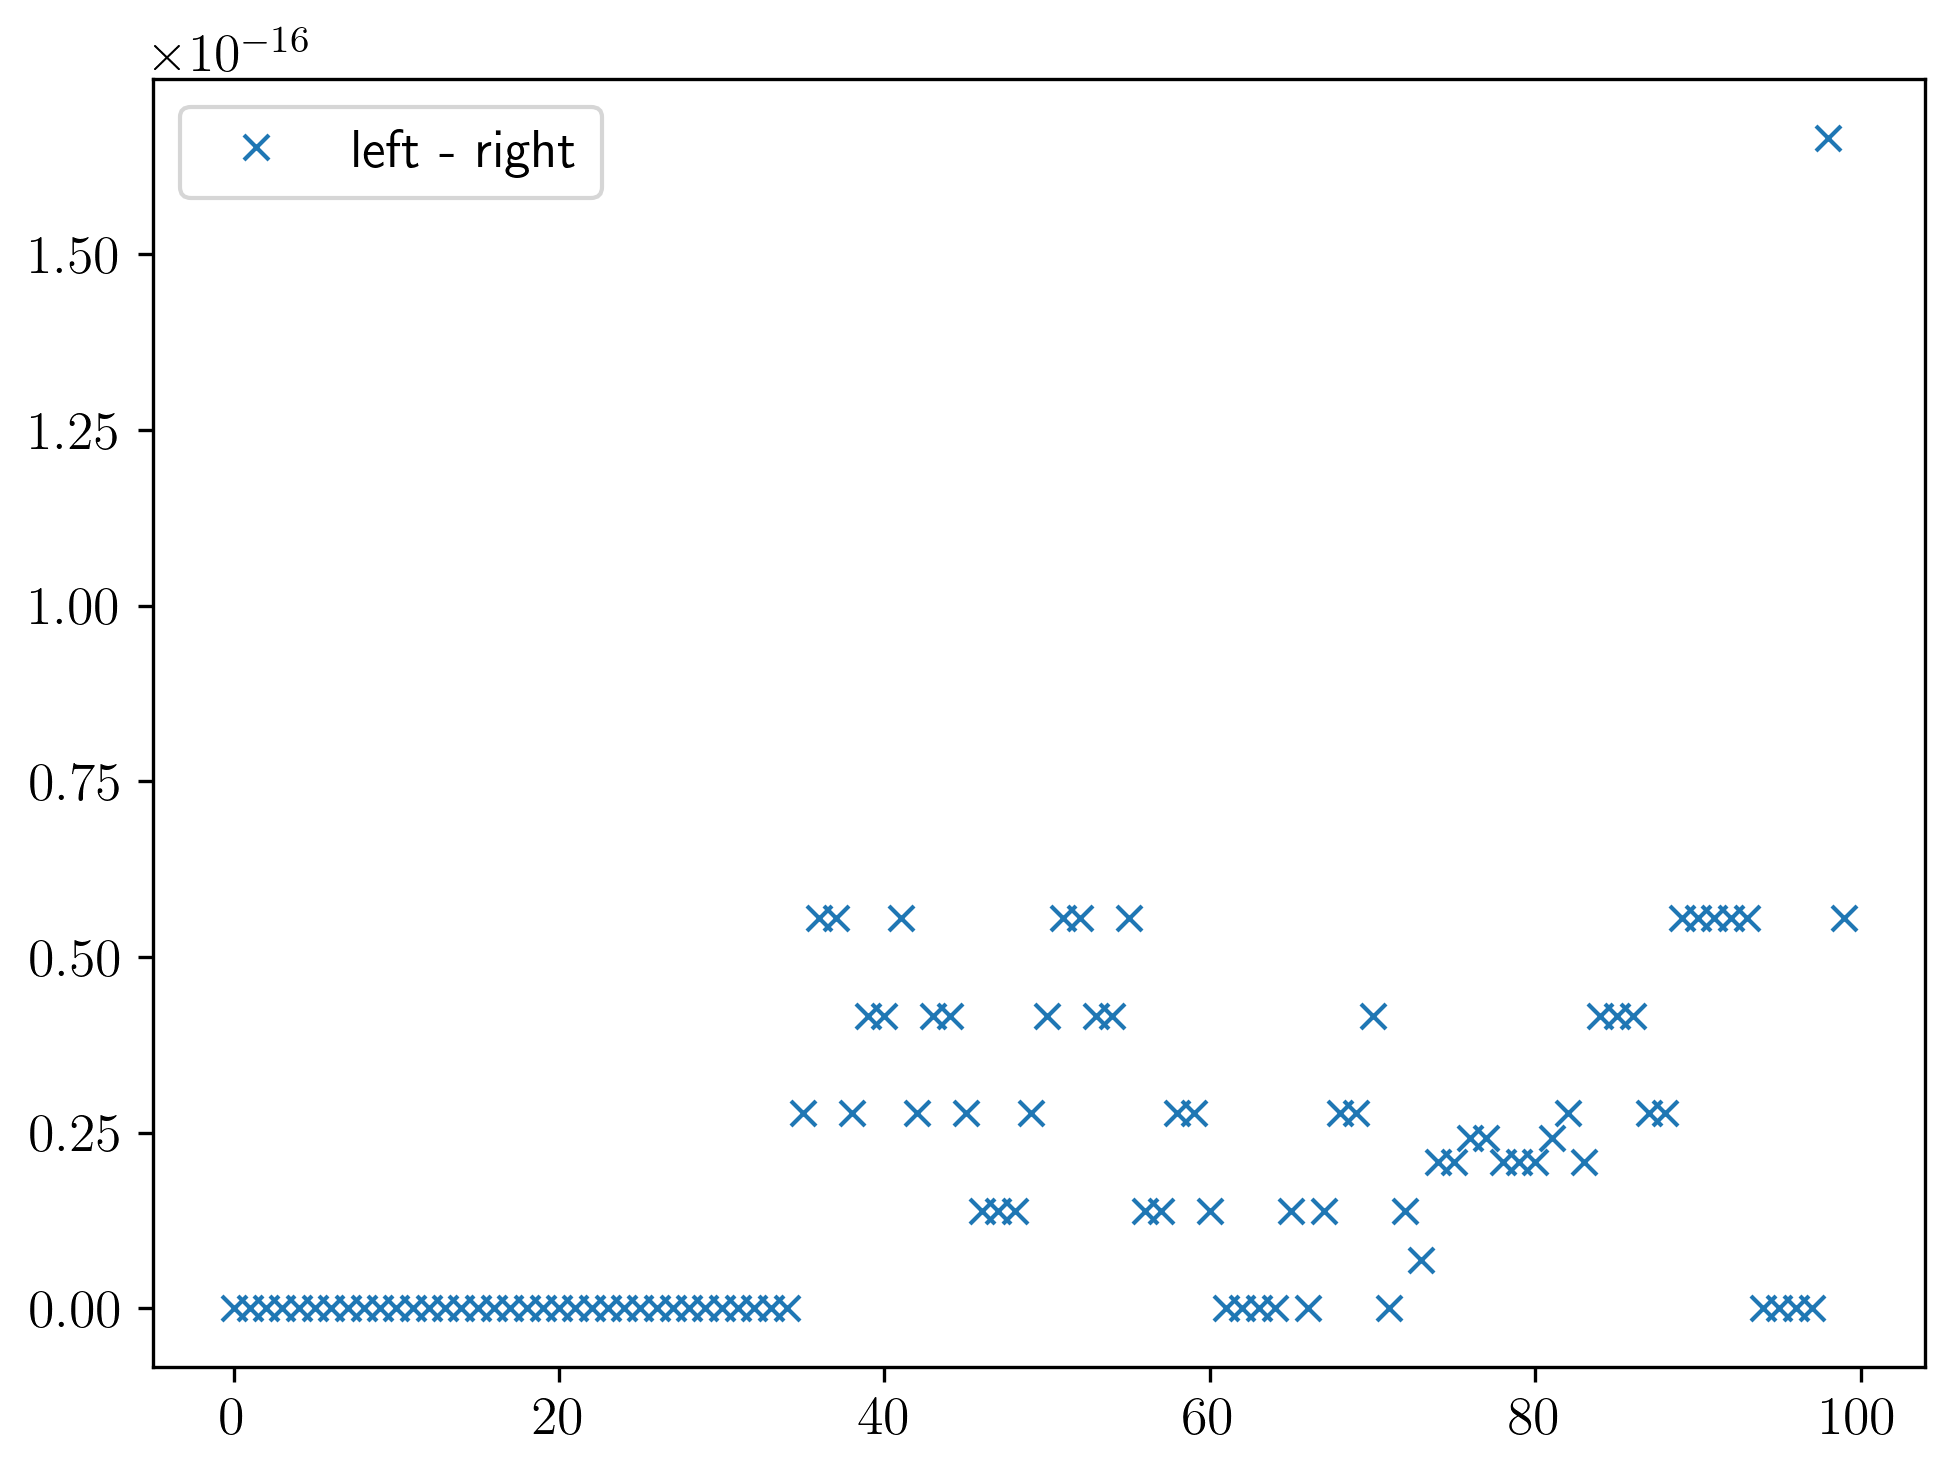

In [195]:
plt.plot(np.abs(np.asarray(exp_vals[0])[:,1] - np.asarray(exp_vals[0])[:,3]),'x', label='left - right')
plt.legend()

In [196]:
def trotter(delta):
    n = 2*half_chain_length + 1

    op_ev_if, op_ev_bulk = U_i_ip1_tJ(Jz, t_up, t_down, J_perp, delta)
    site_i_if, site_ip1_if, site_i_b, site_ip1_b = evolution_mpo_svd_tJ(op_ev_if, op_ev_bulk)

    mpo_start = evolution_mpo_start_tJ(n, site_i_if, site_ip1_if, site_i_b, site_ip1_b)
    mpo_end = evolution_mpo_end_tJ(n, site_i_if, site_ip1_if)

    U_start = mpo_to_matrix(mpo_start)
    U_end = mpo_to_matrix(mpo_end)
    U_trott = U_start @ U_end
    return U_trott

In [197]:
def exact(delta):
    H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, n_holes=1)
    op_ev_exact = sp.linalg.expm(-1j * delta * H_ev)
    return op_ev_exact

In [199]:
def error(Ue, Ut):
    return np.linalg.norm(Ue - Ut, ord='fro')

deltas = np.logspace(-3, -1, 10)
errors = []

for d in deltas:
    print(d)
    Ue = exact(d).toarray()
    Ut = trotter(d)
    errors.append(error(Ue, Ut))

slope = np.polyfit(np.log(deltas), np.log(errors), 1)[0]
print("Scaling exponent:", slope)


0.001


c:\Users\HP\anaconda3\envs\mps\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:412: SparseEfficiencyWarning: splu converted its input to CSC format
  warn('splu converted its input to CSC format', SparseEfficiencyWarning)
c:\Users\HP\anaconda3\envs\mps\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:302: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  warn('spsolve is more efficient when sparse b '


0.0016681005372000592
0.0027825594022071257
0.004641588833612777
0.007742636826811269
0.01291549665014884
0.021544346900318832
0.03593813663804626
0.05994842503189409
0.1
Scaling exponent: 0.9978606563782801
